# Step 2: Microscopic Analysis (Centrality, k-Core, and Degree Distribution)

This notebook computes node centralities and structural groupings to identify major hubs, core-periphery layering, and constraints on the degree distribution. We evaluate:
- **Degree Centrality**: To locate key physical intersection hubs.
- **Betweenness Centrality**: To identify vital flow bottlenecks (gatekeepers) controlling transport paths.
- **k-Core Decomposition**: To distinguish the innermost dense core from the sparse branching periphery.
- **Degree Distribution**: To analyze the bounded nature of physical spatial networks.

In [1]:
import sys
import os

# Add parent directory to path so we can import src
sys.path.append('..')

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_london_network
from src.analyzer import compute_centralities

## 1. Load the Network and Run Centralities

In [2]:
G_L, _, _, _ = load_london_network()
df_micro = compute_centralities(G_L)

print("=== Top 5 Hubs by Degree ===")
print(df_micro.sort_values(by='Degree', ascending=False).head(5)[['Station', 'Degree']])

print("\n=== Top 5 Hubs by Closeness Centrality ===")
print(df_micro.sort_values(by='Closeness Centrality', ascending=False).head(5)[['Station', 'Closeness Centrality']])

print("\n=== Top 5 Gatekeepers by Betweenness Centrality ===")
print(df_micro.sort_values(by='Betweenness Centrality', ascending=False).head(5)[['Station', 'Betweenness Centrality']])

=== Top 5 Hubs by Degree ===
                      Station  Degree
9                Baker Street       7
126  King's Cross St. Pancras       7
246                  Waterloo       6
166             Oxford Circus       6
11                       Bank       6

=== Top 5 Hubs by Closeness Centrality ===
                  Station  Closeness Centrality
166         Oxford Circus              0.000090
227  Tottenham Court Road              0.000089
171      Picadilly Circus              0.000089
25            Bond Street              0.000088
107               Holborn              0.000088

=== Top 5 Gatekeepers by Betweenness Centrality ===
                      Station  Betweenness Centrality
9                Baker Street                0.286755
11                       Bank                0.241993
126  King's Cross St. Pancras                0.235349
166             Oxford Circus                0.232913
261               Whitechapel                0.209546


## 2. Core-Periphery Structure (k-Core Decomposition)

The k-core of a graph is the maximal subgraph where each node has degree at least k. We decompose the network to isolate the core central loop system from peripheral branch lines.

In [3]:
print("Coreness Shell Distribution:")
print(df_micro['Coreness'].value_counts())

k_max = df_micro['Coreness'].max()
print(f"\nMaximum Coreness (k_max): {k_max}")

max_core_stations = df_micro[df_micro['Coreness'] == k_max]['Station'].tolist()
print(f"Number of stations in the innermost ({k_max}-core) shell: {len(max_core_stations)}")
print(f"Innermost core stations (first 15): {max_core_stations[:15]}")

Coreness Shell Distribution:
Coreness
2    166
1    136
Name: count, dtype: int64

Maximum Coreness (k_max): 2
Number of stations in the innermost (2-core) shell: 166
Innermost core stations (first 15): ['Acton Town', 'Aldgate', 'Aldgate East', 'All Saints', 'Alperton', 'Angel', 'Arsenal', 'Baker Street', 'Bank', 'Barbican', 'Barkingside', 'Barons Court', 'Bayswater', 'Bethnal Green', 'Blackfriars']


## 3. Degree Distribution (Scale-Free Test)

Unlike internet or social networks, spatial transportation networks are constrained by planarity (tracks cannot overlap infinitely at a station). We plot the degree distribution to show how node degrees are bounded.

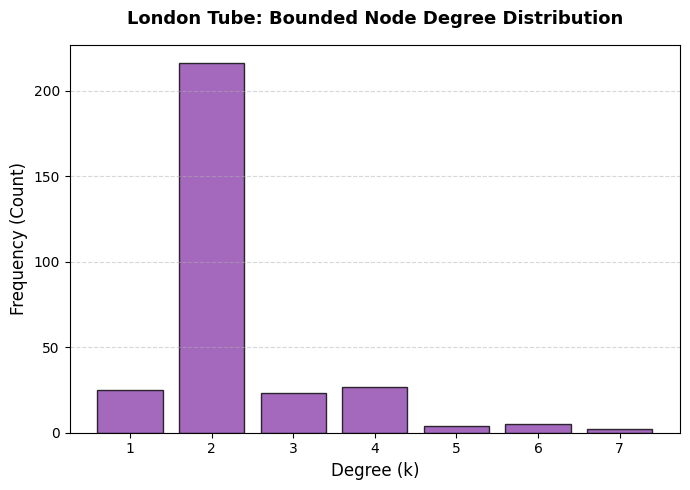

Maximum node degree in the network: 7
This sharp truncation represents the spatial constraints preventing high-degree hubs.


In [4]:
deg_counts = df_micro['Degree'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(deg_counts.index, deg_counts.values, color='#8e44ad', edgecolor='black', alpha=0.8)
plt.xlabel('Degree (k)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.title('London Tube: Bounded Node Degree Distribution', fontsize=13, fontweight='bold', pad=15)
plt.xticks(deg_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

os.makedirs('../latex/figures', exist_ok=True)
plt.savefig('../latex/figures/london_degree_dist.png', dpi=300)
plt.show()

print(f"Maximum node degree in the network: {df_micro['Degree'].max()}")
print("This sharp truncation represents the spatial constraints preventing high-degree hubs.")

## 4. Visualizing Centrality Hotspots

We draw the network, setting node size and color based on Betweenness Centrality to visually pinpoint structural bottleneck hotspots.

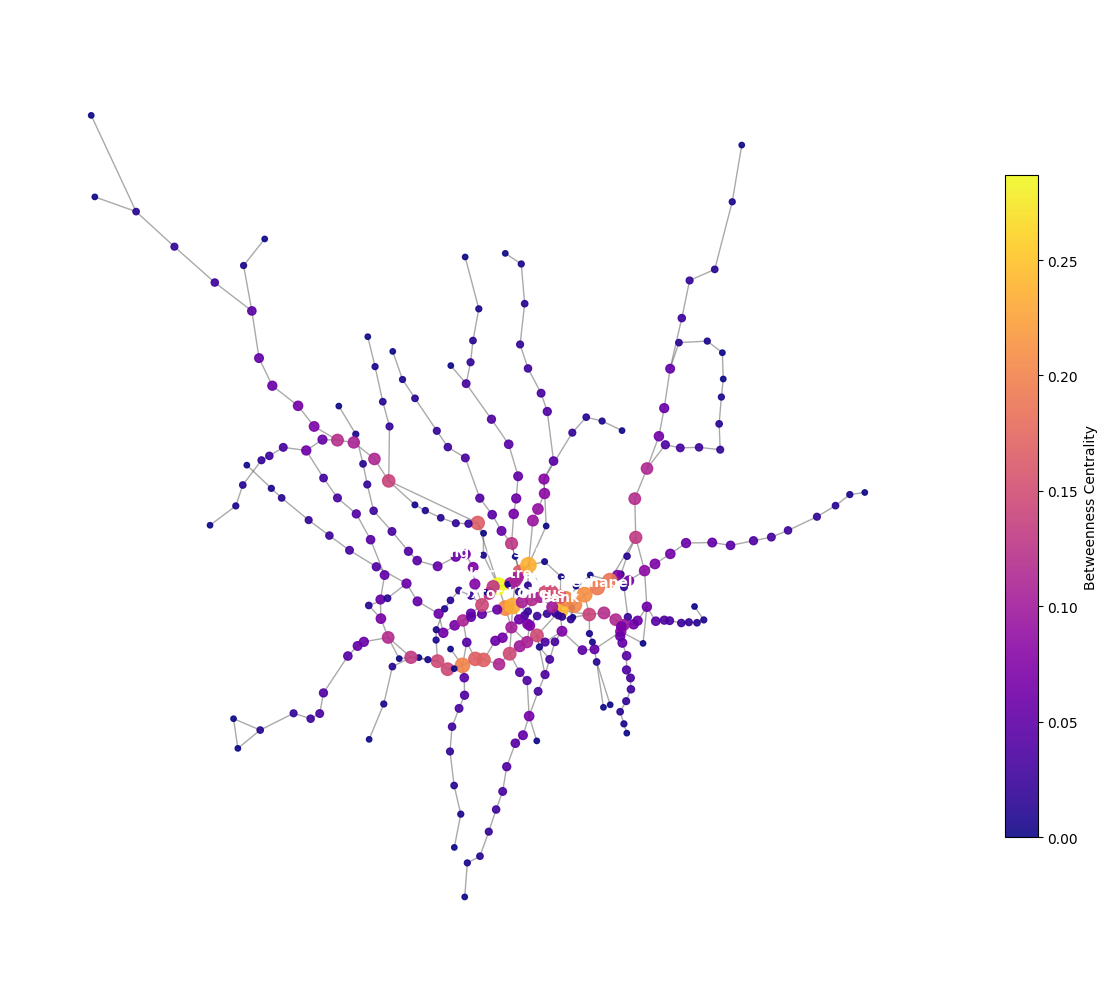

In [5]:
bet_dict = dict(zip(df_micro['Station'], df_micro['Betweenness Centrality']))
node_sizes = [15 + 450 * bet_dict[node] for node in G_L.nodes()]
node_colors = [bet_dict[node] for node in G_L.nodes()]
pos = {node: (data['lon'], data['lat']) for node, data in G_L.nodes(data=True)}

plt.figure(figsize=(12, 10))
plt.gca().set_facecolor('#1a1a1a')  # Dark background for visibility

nx.draw_networkx_edges(G_L, pos, edge_color='#555555', width=1, alpha=0.5)
sc = nx.draw_networkx_nodes(G_L, pos, node_size=node_sizes, node_color=node_colors, 
                            cmap=plt.cm.plasma, alpha=0.9)

plt.colorbar(sc, label='Betweenness Centrality', shrink=0.7)

# Label the top 5 bottleneck stations
top_bottlenecks = df_micro.sort_values(by='Betweenness Centrality', ascending=False).head(5)['Station'].tolist()
label_pos = {name: (pos[name][0], pos[name][1] + 0.005) for name in top_bottlenecks}
nx.draw_networkx_labels(G_L, label_pos, labels={name: name for name in top_bottlenecks}, 
                        font_color='white', font_size=10, font_weight='bold')

plt.title("London Tube: Identifying Structural Bottlenecks (Betweenness Centrality)", 
          color='white', fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Export Centrality Results

In [6]:
os.makedirs('../data_output', exist_ok=True)
df_micro.to_csv("../data_output/london_centralities.csv", index=False)
print("Centralities saved to data_output/london_centralities.csv")

Centralities saved to data_output/london_centralities.csv
